In [ ]:
This changed because we updated script to move the file so ignore.

In [1]:
from datetime import datetime

print(f"Timestamp: {datetime.now()}")

Timestamp: 2026-01-09 14:48:55.573715


# Confirm integrity of files

## Raw and processed data files

In [2]:
import csv
import os
import scanpy as sc
import numpy as np

In [3]:
log_path = "/home/workspace/temp/geo_organized/organization_log.csv"
mismatches = []

with open(log_path, newline="") as f:
    reader = csv.DictReader(f, delimiter=",") #csv
    for row in reader:
        src, dst = row["Source_Path"], row["Destination_Path"]
        if os.path.exists(src) and os.path.exists(dst):
            size_src = os.path.getsize(src)
            size_dst = os.path.getsize(dst)
            if size_src != size_dst:
                mismatches.append((src, dst, size_src, size_dst))
        else:
            mismatches.append((src, dst, "missing", "missing"))

if mismatches:
    print("Size mismatches detected:\n")
    for src, dst, s1, s2 in mismatches:
        print(f"Source: {src}\nDest:   {dst}\nSizes:  {s1} vs {s2}\n")
else:
    print("All copied files match in size.")

Size mismatches detected:

Source: /home/workspace/temp/geo/output-XETG00123__0051689__TMA00309__20251203__231448/morphology.ome.tif
Dest:   /home/workspace/temp/geo_organized/raw/TMA00309_morphology.ome.tif
Sizes:  missing vs missing

Source: /home/workspace/temp/geo/output-XETG00123__0051689__TMA00309__20251203__231448/transcripts.parquet
Dest:   /home/workspace/temp/geo_organized/raw/TMA00309_transcripts.parquet
Sizes:  missing vs missing

Source: /home/workspace/temp/geo/output-XETG00123__0051689__TMA00309__20251203__231448/cell_feature_matrix.h5
Dest:   /home/workspace/temp/geo_organized/processed/TMA00309_cell_feature_matrix.h5
Sizes:  missing vs missing

Source: /home/workspace/temp/geo/output-XETG00123__0051689__TMA00309__20251203__231448/cells.parquet
Dest:   /home/workspace/temp/geo_organized/processed/TMA00309_cells.parquet
Sizes:  missing vs missing

Source: /home/workspace/temp/geo/output-XETG00123__0051689__TMA00309__20251203__231448/cell_boundaries.parquet
Dest:   /home/

In [4]:
with open(log_path, newline="") as f:
    reader = csv.DictReader(f, delimiter=",")
    all_rows = [row for row in reader]

print(f"Checking {len(all_rows)} file pairs...\n")

mismatches = []
for row in all_rows:
    src = row["Source_Path"].strip()
    dst = row["Destination_Path"].strip()

    if os.path.exists(src) and os.path.exists(dst):
        s1 = os.path.getsize(src)
        s2 = os.path.getsize(dst)
        status = "MATCH" if s1 == s2 else "MISMATCH"
        print(f"{status:10} | {os.path.basename(dst):50} | {s1/1e6:10.2f} MB  -->  {s2/1e6:10.2f} MB")
        if s1 != s2:
            mismatches.append((src, dst, s1, s2))
    else:
        print(f"Missing file(s): {src if not os.path.exists(src) else ''} {dst if not os.path.exists(dst) else ''}")
        mismatches.append((src, dst, "missing", "missing"))

if mismatches:
    print("\nSome files differ or are missing:")
    for src, dst, s1, s2 in mismatches:
        print(f"Source: {src}\nDest:   {dst}\nSizes:  {s1} vs {s2}\n")
else:
    print("\nAll copied files match in size.")

Checking 72 file pairs...

Missing file(s): /home/workspace/temp/geo/output-XETG00123__0051689__TMA00309__20251203__231448/morphology.ome.tif 
Missing file(s): /home/workspace/temp/geo/output-XETG00123__0051689__TMA00309__20251203__231448/transcripts.parquet 
Missing file(s): /home/workspace/temp/geo/output-XETG00123__0051689__TMA00309__20251203__231448/cell_feature_matrix.h5 
Missing file(s): /home/workspace/temp/geo/output-XETG00123__0051689__TMA00309__20251203__231448/cells.parquet 
Missing file(s): /home/workspace/temp/geo/output-XETG00123__0051689__TMA00309__20251203__231448/cell_boundaries.parquet 
Missing file(s): /home/workspace/temp/geo/output-XETG00123__0051689__TMA00309__20251203__231448/nucleus_boundaries.parquet 
Missing file(s): /home/workspace/temp/geo/output-XETG00123__0051689__TMA00313__20251203__231448/morphology.ome.tif 
Missing file(s): /home/workspace/temp/geo/output-XETG00123__0051689__TMA00313__20251203__231448/transcripts.parquet 
Missing file(s): /home/workspac

## Processed anndata

Note adata.obsm entries are from neuronal fraction (X_scVI and X_umap)

In [5]:
input_dir = "/home/workspace/private/geo_organized"
adata = sc.read_h5ad(os.path.join(input_dir, 'adata_processed.h5ad'))
adata

AnnData object with n_obs × n_vars = 147036 × 480
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample_id', 'slide_id', 'n_genes_by_counts', 'cell_type', 'cell_class', 'EGFP_Seq1_hi', 'dTomato_Seq2_hi', 'EGFP_dTomato_dual_hi', 'reporter_status', 'innervation_pattern', 'neuron_filter'
    uns: 'cell_type_colors'
    obsm: 'X_scVI', 'X_umap'
    layers: 'counts'

/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Catego

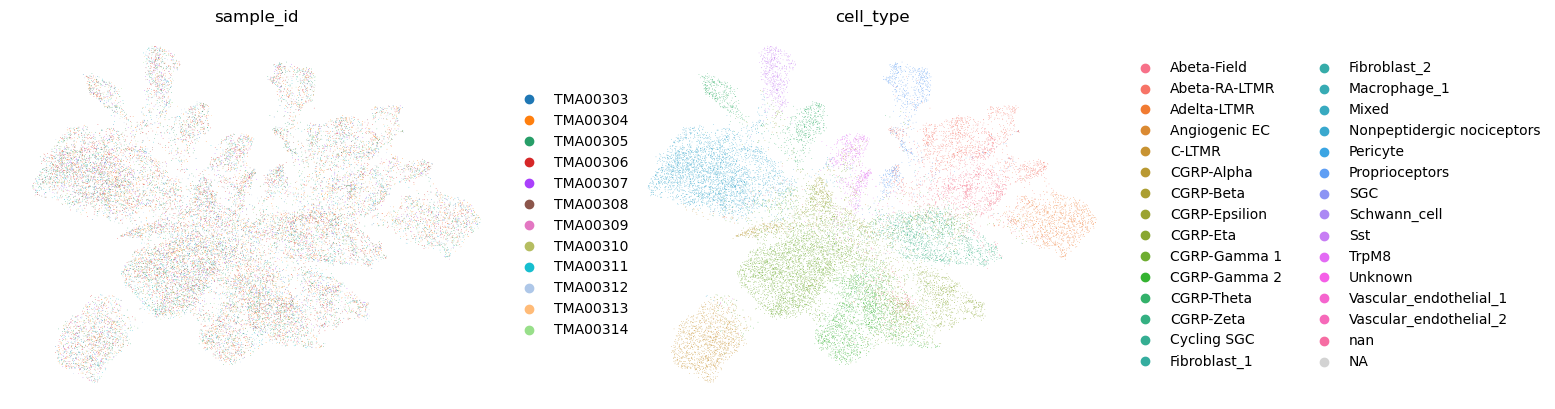

In [6]:
sc.pl.umap(adata, color = ['sample_id', 'cell_type'], frameon = False)

In [7]:
adata.obs.neuron_filter.value_counts()

neuron_filter
NA      83445
Fail    41180
Pass    22411
Name: count, dtype: int64

In [8]:
# Confirm scVI embedding
has_embedding = ~np.isnan(adata.obsm['X_scVI']).any(axis=1)
print(f"# cells with scVI embeddings: {has_embedding.sum()}")

# cells with scVI embeddings: 22411


In [9]:
## After these checks proceeded with deleting the temp hise DL folders to create space to zip the geo_organized folder and upload to HISE.